## 📘 Methodology Overview

### 🧹 Data Cleaning and Preprocessing

To prepare the datasets for room matching, we applied several filtering and transformation steps to ensure that the comparison between reference and supplier rooms is meaningful and efficient:

1. **Invalid Room Name Removal**  
2. **Identifying Shared Properties (`lp_id`)**  
3. **Filtering on Shared Properties**  
4. **Grouping Room Information by Property**  
5. **Merging and Analyzing Room Counts**  
6. **Subsampling for Efficient Evaluation**  
7. **Removing Perfect Duplicates Across Sources**  
8. **Selecting a Representative Example**  

### 🧠 Model Architecture

#### 1. LLM Enrichement (GroqCloud LLaMA3-70B)
#### 2. Embedding Model (all-MiniLM-L6-v2)
#### 3. FAISS Vector Store

### Matching Results & Evaluation


### Next Steps: LLM as a Judge



# Libraries

In [1]:
!pip install faiss-cpu groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import os
import groq
from sentence_transformers import SentenceTransformer
import faiss

# Ubder colab secrets I created a qroq api key and called it qrok
from google.colab import userdata
groq_token=userdata.get('qrok')

client = groq.Groq(api_key=groq_token)

# Data Collection and Processing

In [3]:
# Loading the suppliers data
supp = pd.read_csv("/content/updated_core_rooms.csv")
# Loading the reference data
ref = pd.read_csv("/content/referance_rooms-1737378184366.csv")

In [4]:
supp.head()

,core_room_id,core_hotel_id,lp_id,supplier_room_id,supplier_name,supplier_room_name
0,1,506732,lp7bb6c,200979491,Expedia,Superior Double Room
1,2,509236,lp7c534,200998017,Expedia,"Deluxe Room, Balcony"
2,3,516326,lp7e0e6,201144757,Expedia,Female Dormitory- 3 Beds
3,4,495330,lp78ee2,201028863,Expedia,"Standard Apartment, 2 Bedrooms (6 people)"
4,5,970167,lpecdb7,218116045,Expedia,"Traditional Cottage, 2 Bedrooms, Harbor View"


In [5]:
ref.head()

,hotel_id,lp_id,room_id,room_name
0,13484077,lp23e8ef,1142730702,Double or Twin Room
1,13487663,lp6554de34,1141927122,House
2,13462809,lp6556c3dc,1142722063,Room
3,13530116,lp6555450b,1141968275,Triple Room
4,13530071,lp6557a92c,1142513784,Apartment


In [6]:
ref.room_name.value_counts()

,count
room_name,
One-Bedroom Apartment,3634
Apartment,2875
Two-Bedroom Apartment,2625
Double Room,2358
Holiday Home,1647
...,...
Economy Single Room - Pet Friendly/Non-Smoking,1
King Suite with Balcony and Sea View - Non-Smoking,1
Room (Twin (corona safe room)),1


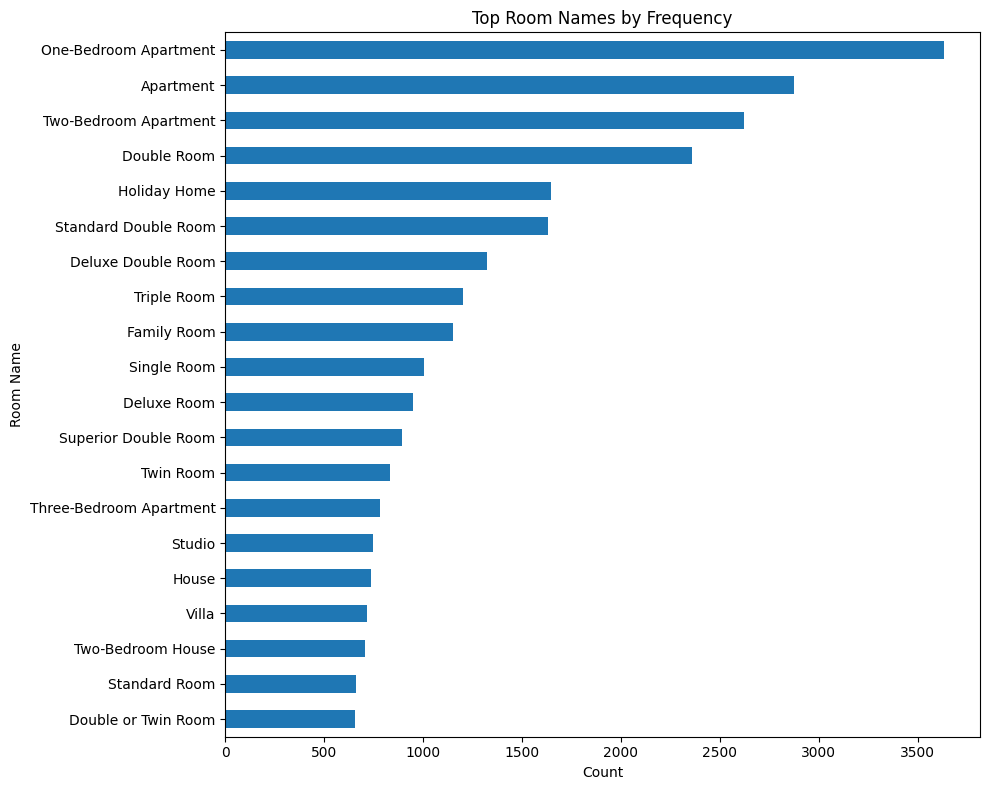

In [7]:
import matplotlib.pyplot as plt

# Get room name counts
room_counts = ref['room_name'].value_counts()

# Plot the top N room names (e.g., top 20 for clarity)
top_n = 20
room_counts.head(top_n).plot(kind='barh', figsize=(10, 8))

plt.xlabel('Count')
plt.ylabel('Room Name')
plt.title('Top Room Names by Frequency')
plt.gca().invert_yaxis()  # Show highest count on top
plt.tight_layout()
plt.show()


As we explore the reference dataset, we notice that there are many distinct rooms that are written in this format : "Room #2170119", "Room #39503141", these rooms do not add any info to our data so we will remove the rows that contain these rooms.

In [8]:

def is_invalid_room_name(room_name):
    # Check if the room name contains "Room #""
    pattern = r'^Room #\d+'
    return bool(re.match(pattern, room_name))

In [9]:
# Step 1: Invalid Room Name Removal
# Remove invalid room names from the reference dataset
ref_valid = ref[~ref['room_name'].apply(is_invalid_room_name)]

# Step 2: Identifying Shared Properties (lp_id)
#lp_id is a common column between both reference and supplier datasets so we will first get the shared ids
shared_lp_ids = set(ref_valid['lp_id']) & set(supp['lp_id'])

# Step 3: Filtering on Shared Properties
# Filter both DataFrames by shared lp_ids
ref_filtered = ref_valid[ref_valid['lp_id'].isin(shared_lp_ids)]
supp_filtered = supp[supp['lp_id'].isin(shared_lp_ids)]


# Step 4: Grouping Room Information by Property
# Group room info (room_id + room_name + supplier_name if available) by lp_id
def group_room_info(df, fields_to_keep, result_column_name):
    return (
        df.groupby('lp_id')[fields_to_keep]
        .apply(lambda x: x.to_dict('records'))
        .reset_index(name=result_column_name)
    )

# Group reference room data (room_id + room_name)
ref_grouped = group_room_info(
    ref_filtered,
    ['room_id', 'room_name'],
    result_column_name='ref_room_info'
)

# Group supplier room data (supplier_room_id + supplier_room_name + supplier_name)
supp_grouped = group_room_info(
    supp_filtered,
    ['supplier_room_id', 'supplier_room_name', 'supplier_name'],
    result_column_name='supplier_room_info'
)

# Step 5: Merging and Analyzing Room Counts
# Merge grouped DataFrames
merged = pd.merge(supp_grouped, ref_grouped, on='lp_id', how='inner')

# Step 6: Add count of rooms for both reference and supplier
merged['num_supplier_rooms'] = merged['supplier_room_info'].apply(len)
merged['num_ref_rooms'] = merged['ref_room_info'].apply(len)

# Step 7: Sort by number of reference rooms in descending order
merged = merged.sort_values(by='num_ref_rooms', ascending=False).reset_index(drop=True)

# Step 8: For this POC we will consider number of rooms in the range of [2, 29]
# there are many properties with a high number of rooms and in our POC we will work with small cardinality to not use many
# llm api calls
filtered = merged[
    (merged['num_ref_rooms'].between(2, 29)) &
    (merged['num_supplier_rooms'].between(2, 29))
].reset_index(drop=True)

# Step 9: Keep only rows where room names differ: for some lp_ids we notices that both suppliers and references
# have the same properties listed, that is the perfect case in real life that will yield a score of 1
# in our use case we will seek an example where we may have some extra rooms from the reference side for example just to
# see how our llm can handle this
def room_names_set(info_list, key):
    return set(room[key] for room in info_list)

filtered = filtered[
    filtered.apply(
        lambda row: room_names_set(row['supplier_room_info'], 'supplier_room_name') !=
                    room_names_set(row['ref_room_info'], 'room_name'),
        axis=1
    )
].reset_index(drop=True)


In [10]:
filtered.head(30)

,lp_id,supplier_room_info,ref_room_info,num_supplier_rooms,num_ref_rooms
0,lp936ac,"[{'supplier_room_id': 316163672, 'supplier_roo...","[{'room_id': 1141898158, 'room_name': 'Premium...",18,28
1,lp31b8d,"[{'supplier_room_id': 200913456, 'supplier_roo...","[{'room_id': 4584309, 'room_name': 'Double or ...",13,28
2,lp4a42d,"[{'supplier_room_id': 200758652, 'supplier_roo...","[{'room_id': 1142309343, 'room_name': 'Comfort...",29,28
3,lp1e3c5b,"[{'supplier_room_id': 219021461, 'supplier_roo...","[{'room_id': 1143514130, 'room_name': 'Apartme...",26,25
4,lpa922a,"[{'supplier_room_id': 221711256, 'supplier_roo...","[{'room_id': 204303615, 'room_name': 'Family R...",14,25
5,lp918ca,"[{'supplier_room_id': 232518259, 'supplier_roo...","[{'room_id': 1142832384, 'room_name': '[2 High...",24,24
6,lp4f21f,"[{'supplier_room_id': 316344728, 'supplier_roo...","[{'room_id': 1142440894, 'room_name': 'Classic...",15,23
7,lp39858,"[{'supplier_room_id': 201115750, 'supplier_roo...","[{'room_id': 1142938808, 'room_name': 'Villa D...",25,23
8,lp8acc6,"[{'supplier_room_id': 201404556, 'supplier_roo...","[{'room_id': 746100312, 'room_name': 'Studio'}...",7,23
9,lp31e1f,"[{'supplier_room_id': 249396, 'supplier_room_n...","[{'room_id': 171060903, 'room_name': 'Single B...",7,22


After checking the filtered dataframe and the room names we will use the row 28 as an example given that there are common and different rows between
he reference and the supplier and can serve as starting point for room naming extraction (room name cleaning) and enrichement (room description)

In [11]:
filtered.iloc[28].lp_id

'lp9058e'

In [12]:
filtered.iloc[28].supplier_room_info[0]

{'supplier_room_id': 202359717,
 'supplier_room_name': 'Double Room for 1 adult, Non Smoking (Japanese Style)',
 'supplier_name': 'Expedia'}

In [13]:
supp_lp9058e = supp.query("lp_id == 'lp9058e'")[["supplier_room_name", "supplier_room_id", "supplier_name", "lp_id"]]
ref_lp9058e = ref.query("lp_id == 'lp9058e'")[["room_name", "room_id", "lp_id"]]

In [14]:
supp_lp9058e.shape

(14, 4)

In [15]:
ref_lp9058e.shape

(18, 3)

# Model Architecture


## LLM Enrichement (GroqCloud LLaMA3-70B)

A 70-billion parameter LLM is used to interpret and normalize room names. This large model can infuse domain knowledge, provide additional context, correct errors, and normalize terminology. The choice of a powerful LLM ensures high-quality rewriting of room descriptions, which improves the next step’s effectiveness.

Each raw room name is first cleaned. We use a prompt-engineered LLM (llama3-70b-8192 via GroqCloud) to generate a structured description for every room.
The LLM is instructed (via a carefully tuned prompt) to extract key attributes such as:

Room type

- View
- Amenities (e.g. kitchen, non-smoking)
- Floor level and room size (if available)

It returns:


- A normalized cleaned_name
- A concise, grammatically correct description


In [16]:

PROMPT_TEMPLATE = """[INSTRUCTION]
Clean hotel room names by:
1. Removing ALL amenities, bed counts, floor numbers, accessibility info, room size (sqm), meal plans, and location indicators
   (e.g., "3 Beds", "Ground Floor", "Non Smoking", "with Balcony", "Japanese Dinner", "46 sqm").
2. Retain ONLY the core room class or type (e.g., "Junior Suite", "Japanese-Western Style Room").
3. For descriptions: Include ALL removed elements in a natural, grammatically correct sentence.
   - Describe non-smoking status, kitchen, bed count, floor level, and room size when available.
   - Do NOT include promotional content (e.g., “Adventure World ticket”).

Format EXACTLY like this and avoid failure messages

Input: {input}
Cleaned Name: {cleaned_name}|Description: {description}

Examples:
1. Input: Deluxe Room with Balcony
Cleaned Name: Deluxe Room|Description: Deluxe room with balcony access

2. Input: Sea View Suite
Cleaned Name: Suite|Description: Suite offering panoramic sea views

3. Input: Female Dormitory - 3 Beds
Cleaned Name: Female Dormitory|Description: Female dormitory with 3 beds

4. Input: Classic Room - Ground Floor
Cleaned Name: Classic Room|Description: Classic room located on the ground floor

5. Input: Economy Double Room with Shared Bathroom
Cleaned Name: Economy Double Room|Description: Economy double room with shared bathroom

6. Input: Annex Japanese-Western Style Room A, Balcony, NonSmoking
Cleaned Name: Annex Japanese-Western Style Room A|Description: Japanese-Western style room with balcony, non-smoking

7. Input: Junior Suite Accessible (No children included)
Cleaned Name: Junior Suite|Description: Accessible junior suite (no children included)

8. Input: Family Room for 4 adult, Non Smoking (with Kitchen, 13-14th floors, 46 sqm)
Cleaned Name: Family Room|Description: Family room for 4 adults, non-smoking, with kitchen, located on the 13-14th floors, and measuring 46 sqm.

Now process:
Input: {new_input}
"""

# Example usage
input_string = "Family Room for 4 adult, Non Smoking (with Kitchen, 13-14th floors, 46 sqm)"

# Inject the input string dynamically
final_prompt = PROMPT_TEMPLATE.format(
    input=input_string,
    cleaned_name="",     # Leave blank, model will generate
    description="",       # Leave blank, model will generate
    new_input=input_string
)

# print(final_prompt)


def process_room(name):
    full_prompt = PROMPT_TEMPLATE + f"Input: {name}\n"

    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": full_prompt}],
            model="llama3-70b-8192",
            temperature=0.0,
            max_tokens=100,
            stop=["Input:"]
        )

        # Parse response
        raw_output = response.choices[0].message.content
        if "|Description:" in raw_output:
            cleaned, desc = raw_output.split("|Description:", 1)
            cleaned = cleaned.replace("Cleaned Name:", "")
            return cleaned.strip(), desc.strip().capitalize()
        return name, "Description generation failed"

    except Exception as e:
        print(f"Error processing {name}: {str(e)}")
        return name, "Processing error"

In [17]:
supp_lp9058e

,supplier_room_name,supplier_room_id,supplier_name,lp_id
207955,"Double Room for 1 adult, Non Smoking (Japanese...",202359717,Expedia,lp9058e
213418,Japanese Style Double Room for 2 people - Non ...,202314907,Expedia,lp9058e
221763,"Residential Twin Room, Non Smoking (with Kitch...",202314917,Expedia,lp9058e
228494,"Moderate Double Room for 1 adult, Non Smoking",202359705,Expedia,lp9058e
230975,"Superior Double Room Single Use, Non Smoking",202359709,Expedia,lp9058e
232970,"Residential Double Room for 1 adult, Non Smoki...",202359720,Expedia,lp9058e
235296,"Superior Twin Room for 2 adults, Non Smoking",201584885,Expedia,lp9058e
237071,"Moderate Twin Room for 2 adults, Non Smoking",201510644,Expedia,lp9058e
237820,"Residential Double Room, Non Smoking (with Kit...",201757812,Expedia,lp9058e
238596,"Moderate Double Room for 2 adults, Non Smoking",201584870,Expedia,lp9058e


In [18]:
supp_lp9058e[['clean_room_name', 'description']] = supp_lp9058e['supplier_room_name'].apply(
    lambda name: pd.Series(process_room(name))
)
ref_lp9058e[['clean_room_name', 'description']] = ref_lp9058e['room_name'].apply(
    lambda name: pd.Series(process_room(name))
)

In [19]:
supp_lp9058e.head()

,supplier_room_name,supplier_room_id,supplier_name,lp_id,clean_room_name,description
207955,"Double Room for 1 adult, Non Smoking (Japanese...",202359717,Expedia,lp9058e,Double Room,"Double room for 1 adult, non-smoking, in japan..."
213418,Japanese Style Double Room for 2 people - Non ...,202314907,Expedia,lp9058e,Japanese Style Double Room,"Japanese style double room for 2 people, non-s..."
221763,"Residential Twin Room, Non Smoking (with Kitch...",202314917,Expedia,lp9058e,Residential Twin Room,"Residential twin room, non-smoking, with kitch..."
228494,"Moderate Double Room for 1 adult, Non Smoking",202359705,Expedia,lp9058e,Moderate Double Room,"Moderate double room for 1 adult, non-smoking"
230975,"Superior Double Room Single Use, Non Smoking",202359709,Expedia,lp9058e,Superior Double Room,"Superior double room for single use, non-smoking"


In [20]:
ref_lp9058e.head()

,room_name,room_id,lp_id,clean_room_name,description
82846,Japanese Style Double Room for 2 people - Non ...,1142577261,lp9058e,Japanese Style Double Room,"Japanese style double room for 2 people, non-s..."
82847,"Family Twin + Queen Room 4 adults, Non Smoking...",1142577270,lp9058e,Family Twin + Queen Room,"Family room for 4 adults, non-smoking, with ki..."
82848,"Moderate Double Room for 1 adult, Non Smoking",1142577273,lp9058e,Moderate Double Room,"Moderate double room for 1 adult, non-smoking"
82849,"Family Room for 3 adult, Non Smoking (with Kit...",1142577277,lp9058e,Family Room,"Family room for 3 adults, non-smoking, with ki..."
82850,"Premier Twin Room for 3 adults, Non Smoking",1142577286,lp9058e,Premier Twin Room,"Premier twin room for 3 adults, non-smoking"


## Embedding Model (all-MiniLM-L6-v2)

To perform room name matching between reference and supplier datasets, we will first generate a  dense vector representations (embeddings) of the room data using a pre-trained sentence transformer model. Each room will be represented by concatenating its cleaned name and description.

In [21]:
# Embeddings
from sentence_transformers import SentenceTransformer
embed_model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and solid baseline

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

We encode these texts using the model with `normalize_embeddings=True`, which ensures that each embedding has unit length.

This normalization is critical because it enables us to use **cosine similarity** as the **similarity metric** during retrieval, simply by computing the inner product of the vectors.

In [22]:
def embed_dataframe(df, model):
    combined_text = df['clean_room_name'] + ' - ' + df['description']
    # by normalizing the embeddings we are ensuring that each embedding vector has unit length (i.e., its L2 norm is 1)
    embeddings = model.encode(combined_text.tolist(), normalize_embeddings=True)
    return embeddings

In [23]:
# Create embeddings
ref_embeddings = embed_dataframe(ref_lp9058e, embed_model)
supplier_embeddings = embed_dataframe(supp_lp9058e, embed_model)

## FAISS Vectore Store

After generating normalized embeddings for both reference and supplier rooms, we used FAISS (IndexFlatIP) to build an efficient similarity index on the supplier embeddings. Since the embeddings were already normalized, using inner product (IndexFlatIP) is mathematically equivalent to computing cosine similarity.

In [24]:
# Initialize FAISS index
import faiss
embedding_dim = supplier_embeddings.shape[1]


# We are here
index = faiss.IndexFlatIP(embedding_dim)  # Inner product = cosine if embeddings are normalized
index.add(supplier_embeddings)



# Matching Results & Evaluation


We will now Evaluate how this setup matches our room by looping over all the reference rooms from the hotel "lp9058e".

In [29]:
import json


scores_results = []
cupid_results_mock = []
ref_names = []
matched_names = []
match_scores = []



for i in range(len(ref_lp9058e)):
    query_embedding = ref_embeddings[i].reshape(1, -1)
    top_k = 1
    scores, indices = index.search(query_embedding, top_k)

    best_match_index = indices[0][0]
    score = scores[0][0]

    # Reference info
    ref_row = ref_lp9058e.iloc[i]
    ref_name = ref_row['clean_room_name']
    ref_description = ref_row['description']
    ref_room_id = ref_row.get('room_id', '')
    ref_room_name = ref_row.get('room_name', '')
    lp_id = ref_row['lp_id']

    # Matched supplier info
    match_row = supp_lp9058e.iloc[best_match_index]
    match_supplier_room_name = match_row['clean_room_name']
    match_supplier_room_index = match_row['supplier_room_id']
    match_supplier_name = match_row['supplier_name']
    match_supplier_room_description = match_row['description']
    match_supplier_room_raw_name = match_row['supplier_room_name']


    ref_names.append(ref_name)
    matched_names.append(match_supplier_room_name)
    match_scores.append(score)


    print(f"[{i}] Reference Room: {ref_name} ")
    print(f"     Best Match Supplier Room Name: {match_supplier_room_name} (score: {score:.3f})\n")



    scores_results.append({
        "reference": ref_name,
        "match": match_supplier_room_name,
        "score": score
    })

    # Structured output
    result_obj = {
        "cleanRoomName": ref_name,
        "mappedRooms": [
            {
                "cleanSupplierRoomName": match_supplier_room_name,
                "roomDescription": match_supplier_room_description,
                "score": round(float(score), 3),
                "supplierId": match_supplier_name.lower(),
                "supplierRoomId": str(match_supplier_room_index),
                "supplierRoomName": match_supplier_room_raw_name
            }
        ],
        "propertyId": lp_id,
        "roomDescription": ref_description,
        "roomId": str(ref_room_id),
        "roomName": ref_room_name
    }
    cupid_results_mock.append(result_obj)

[0] Reference Room: Japanese Style Double Room 
     Best Match Supplier Room Name: Japanese Style Double Room (score: 1.000)

[1] Reference Room: Family Twin + Queen Room 
     Best Match Supplier Room Name: Residential Twin Room (score: 0.829)

[2] Reference Room: Moderate Double Room 
     Best Match Supplier Room Name: Moderate Double Room (score: 1.000)

[3] Reference Room: Family Room 
     Best Match Supplier Room Name: Residential Twin Room (score: 0.740)

[4] Reference Room: Premier Twin Room 
     Best Match Supplier Room Name: Premier Twin Room (score: 1.000)

[5] Reference Room: Twin Room 
     Best Match Supplier Room Name: Twin Room (score: 0.988)

[6] Reference Room: Family Room 
     Best Match Supplier Room Name: Residential Double Room (score: 0.738)

[7] Reference Room: Moderate Twin Room 
     Best Match Supplier Room Name: Moderate Twin Room (score: 1.000)

[8] Reference Room: Family Room 
     Best Match Supplier Room Name: Residential Double Room (score: 0.718)



## Model Evaluation

After generating the match results and their similarity scores, we organized them into a structured table to evaluate the performance of the matching system.

We assessed the quality of the matches using two criteria:

Exact Match: This metric checks whether the predicted supplier room name is identical to the reference room name. It reflects strict string-level equality between the two.

Soft Match: This metric considers a match to be acceptable if the similarity score (based on cosine similarity) is equal to or greater than a defined threshold, in this case 0.9. This allows for minor differences in wording while still recognizing semantically correct matches.

In [26]:
scores_results = pd.DataFrame(scores_results)
threshold = 0.9


# Add evaluation columns
scores_results['exact_match'] = scores_results['reference'] == scores_results['match']
scores_results['soft_match'] = scores_results['score'] >= threshold

# Compute metrics
total = len(scores_results)
exact = scores_results['exact_match'].sum()
soft = scores_results['soft_match'].sum()
avg_score = scores_results['score'].mean()

# Print summary
print("\n----- Model Evaluation Summary -----")
print(f"Total Matches Evaluated: {total}")
print(f"✅ Exact Match Accuracy: {exact / total:.2%} ({exact}/{total})")
print(f"🟡 Soft Accuracy (score ≥ 0.9): {soft / total:.2%} ({soft}/{total})")
print(f"📊 Average Score: {avg_score:.3f}")
print(f"⚠️ Low-Confidence Matches (< 0.9): {total - soft}")


----- Model Evaluation Summary -----
Total Matches Evaluated: 18
✅ Exact Match Accuracy: 77.78% (14/18)
🟡 Soft Accuracy (score ≥ 0.9): 77.78% (14/18)
📊 Average Score: 0.944
⚠️ Low-Confidence Matches (< 0.9): 4


## Model Explainability

We want to see what happened with the rooms that were mismatched so we plot in green the rooms well matched and in Red the rooms that the model didn't get.

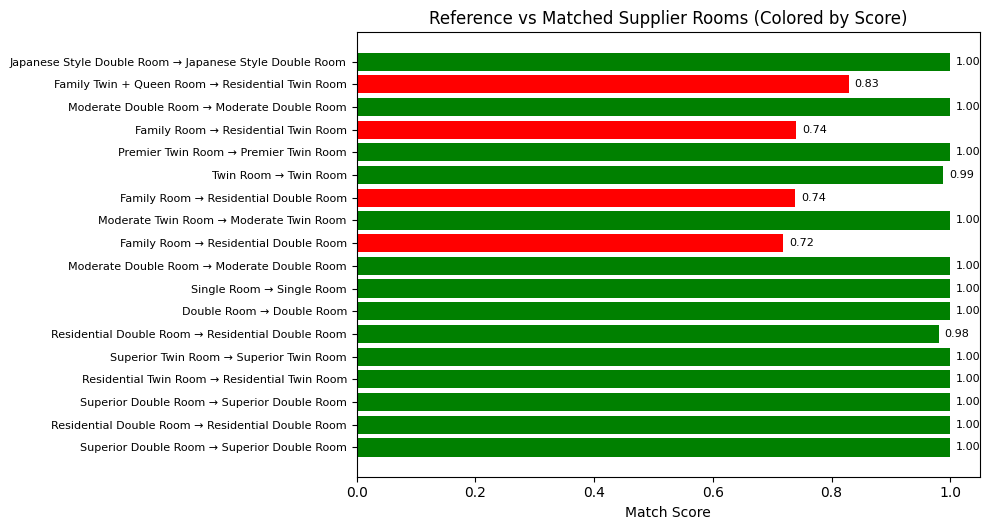

In [36]:
# Labels for Y-axis: Reference -> Match
labels = [f"{ref} → {match}" for ref, match in zip(ref_names, matched_names)]
colors = ['green' if score >= 0.9 else 'red' for score in match_scores]

# Plot
fig, ax = plt.subplots(figsize=(10, len(labels) * 0.3))
y_pos = range(len(labels))

ax.barh(y_pos, match_scores, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()  # Highest score on top
ax.set_xlabel('Match Score')
ax.set_title('Reference vs Matched Supplier Rooms (Colored by Score)')

# Optional: Add score labels inside bars
for i, score in enumerate(match_scores):
    ax.text(score + 0.01, i, f"{score:.2f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

As we can see because we don't have any Family room from the supplier's room names list for this hotel, the model tried to match the nearest room to family room.

In [39]:
[name for name in supp_lp9058e.clean_room_name if "family" in name.lower()]

[]

# Next Steps: LLMs As A Judge

After computing cosine similarity, there may be cases where multiple supplier rooms yield very similar scores for the same reference room. In such cases, the similarity alone is not sufficient to confidently choose the correct match. To address this, we propose an LLM-based judging step:
A dedicated prompt will present the reference room description along with the top-N most similar supplier descriptions. The LLM will then evaluate these candidates and select the most appropriate match based on semantic alignment.
This extra step helps resolve borderline cases with subtle differences, increasing the system’s precision and reliability in real-world deployments.